In [1]:
import pandas as pd

X_train = pd.read_csv("X_train_clean.csv")
X_test = pd.read_csv("X_test_clean.csv")
y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")

In [6]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Load Data
X_train = pd.read_csv("X_train_clean.csv")
X_test = pd.read_csv("X_test_clean.csv")

y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

# Baseline Logistic Regression
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=5000,
    random_state=42,
    n_jobs=-1
)

# Train
lr.fit(X_train, y_train)

# Predictions
train_pred = lr.predict(X_train)
test_pred = lr.predict(X_test)

# In-Sample Performance
print("="*50)
print("IN-SAMPLE PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_train, train_pred))
print("Precision:", precision_score(y_train, train_pred, average='weighted'))
print("Recall   :", recall_score(y_train, train_pred, average='weighted'))
print("F1 Score :", f1_score(y_train, train_pred, average='weighted'))

# Out-of-Sample Performance
print("\n" + "="*50)
print("OUT-OF-SAMPLE PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred, average='weighted'))
print("Recall   :", recall_score(y_test, test_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, test_pred, average='weighted'))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, test_pred))

IN-SAMPLE PERFORMANCE
Accuracy : 0.769513758819541
Precision: 0.8753264787817127
Recall   : 0.769513758819541
F1 Score : 0.8053965211407557

OUT-OF-SAMPLE PERFORMANCE
Accuracy : 0.4090787359400107
Precision: 0.684996095323458
Recall   : 0.4090787359400107
F1 Score : 0.47891044343423816

Classification Report
              precision    recall  f1-score   support

           0       0.14      0.23      0.17      1525
           1       0.00      0.00      0.00      1667
           2       0.06      0.26      0.09      1040
           3       0.12      0.39      0.18      1012
           4       0.77      0.20      0.31      4827
           5       0.13      0.08      0.10      1388
           6       0.22      0.72      0.34      1231
           7       0.93      0.54      0.68     17182

    accuracy                           0.41     29872
   macro avg       0.30      0.30      0.24     29872
weighted avg       0.68      0.41      0.48     29872



In [3]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Load Data
X_train = pd.read_csv("X_train_clean.csv")
X_test = pd.read_csv("X_test_clean.csv")

y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

# Split training data into 80% train and 20% validation
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

print("Training Shape:", X_train_sub.shape)
print("Validation Shape:", X_val.shape)

# Base Logistic Regression
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)

# Hyperparameter Grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'newton-cg'],
    'penalty': ['l2']
}

# Grid Search
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)

# Fit
grid_search.fit(X_train_sub, y_train_sub)

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)

# Best Model
best_lr = grid_search.best_estimator_

# In-Sample Performance
train_pred = best_lr.predict(X_train_sub)

print("\n" + "="*50)
print("IN-SAMPLE PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_train_sub, train_pred))
print("Precision:", precision_score(y_train_sub, train_pred, average='weighted'))
print("Recall   :", recall_score(y_train_sub, train_pred, average='weighted'))
print("F1 Score :", f1_score(y_train_sub, train_pred, average='weighted'))

# Validation Performance
val_pred = best_lr.predict(X_val)

print("\n" + "="*50)
print("VALIDATION PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_val, val_pred))
print("Precision:", precision_score(y_val, val_pred, average='weighted'))
print("Recall   :", recall_score(y_val, val_pred, average='weighted'))
print("F1 Score :", f1_score(y_val, val_pred, average='weighted'))

# Out-of-Sample Performance
test_pred = best_lr.predict(X_test)

print("\n" + "="*50)
print("OUT-OF-SAMPLE PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred, average='weighted'))
print("Recall   :", recall_score(y_test, test_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, test_pred, average='weighted'))

print("\nClassification Report")
print(classification_report(y_test, test_pred))

Training Shape: (119167, 17)
Validation Shape: (29792, 17)
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best Parameters:
{'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}

Best Cross Validation Score:
0.8097594560179235

IN-SAMPLE PERFORMANCE
Accuracy : 0.7755334950112027
Precision: 0.8763798673071683
Recall   : 0.7755334950112027
F1 Score : 0.8102316333292358

VALIDATION PERFORMANCE
Accuracy : 0.779907357679914
Precision: 0.8785564412296964
Recall   : 0.779907357679914
F1 Score : 0.8137297151793186

OUT-OF-SAMPLE PERFORMANCE
Accuracy : 0.41466925549009104
Precision: 0.6786622789804728
Recall   : 0.41466925549009104
F1 Score : 0.480994442042102

Classification Report
              precision    recall  f1-score   support

           0       0.16      0.27      0.20      1525
           1       0.00      0.00      0.00      1667
           2       0.05      0.22      0.08      1040
           3       0.13      0.39      0.20      1012
           4       0.76      0.18      0.

In [7]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model": ["Baseline LR", "Tuned LR"],
    "Accuracy": [
        accuracy_score(y_test, lr.predict(X_test)),
        accuracy_score(y_test, best_lr.predict(X_test))
    ],
    "Precision": [
        precision_score(y_test, lr.predict(X_test), average='weighted'),
        precision_score(y_test, best_lr.predict(X_test), average='weighted')
    ],
    "Recall": [
        recall_score(y_test, lr.predict(X_test), average='weighted'),
        recall_score(y_test, best_lr.predict(X_test), average='weighted')
    ],
    "F1 Score": [
        f1_score(y_test, lr.predict(X_test), average='weighted'),
        f1_score(y_test, best_lr.predict(X_test), average='weighted')
    ]
})

print(comparison.round(4))

         Model  Accuracy  Precision  Recall  F1 Score
0  Baseline LR    0.4091     0.6850  0.4091    0.4789
1     Tuned LR    0.4147     0.6787  0.4147    0.4810


In [5]:
print(hasattr(lr, "classes_"))

False


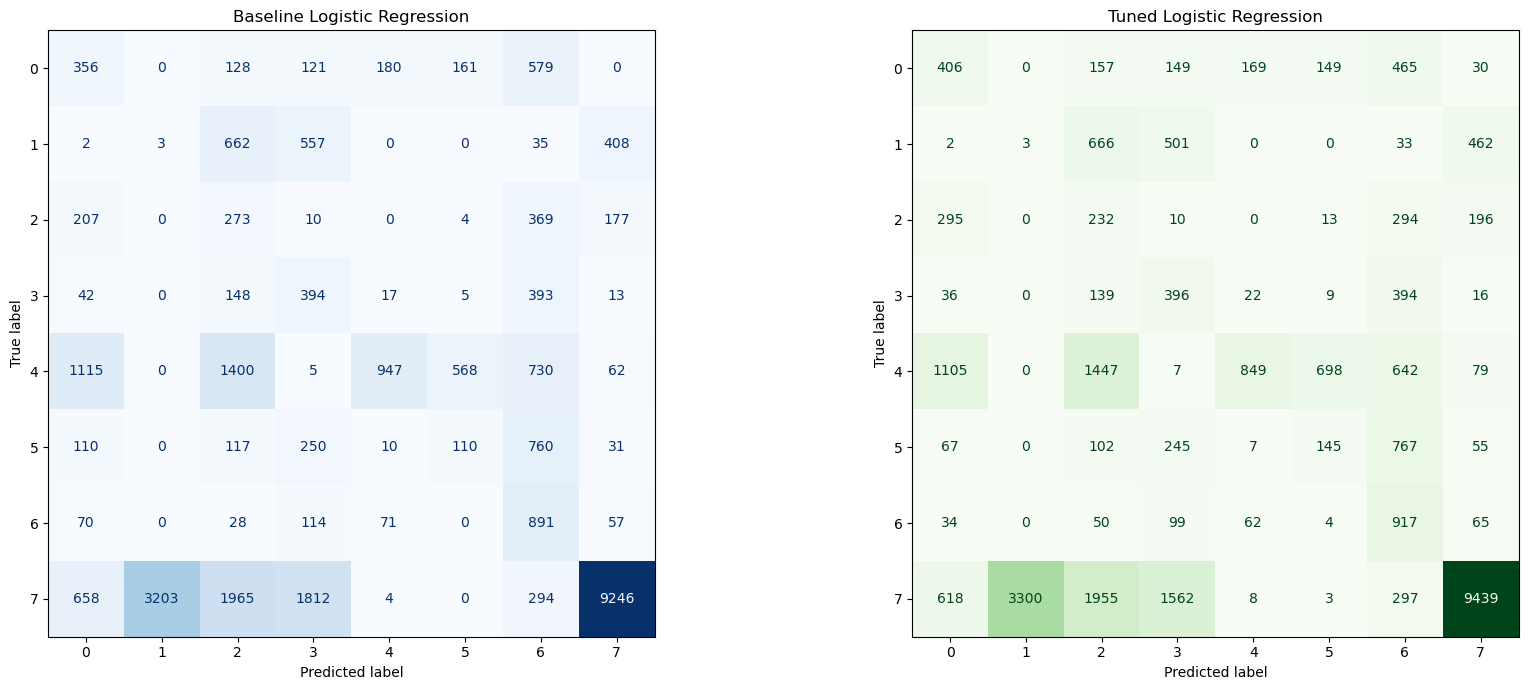

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Predictions
baseline_pred = lr.predict(X_test)
tuned_pred = best_lr.predict(X_test)

# Confusion Matrices
cm_baseline = confusion_matrix(y_test, baseline_pred)
cm_tuned = confusion_matrix(y_test, tuned_pred)

# Plot Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Baseline Logistic Regression
ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=lr.classes_
).plot(ax=axes[0], cmap="Blues", colorbar=False)

axes[0].set_title("Baseline Logistic Regression")

# Tuned Logistic Regression
ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=best_lr.classes_
).plot(ax=axes[1], cmap="Greens", colorbar=False)

axes[1].set_title("Tuned Logistic Regression")

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
from sklearn.metrics import classification_report

# Predictions
baseline_pred = lr.predict(X_test)
tuned_pred = best_lr.predict(X_test)

# Classification Reports as DataFrames
baseline_report = pd.DataFrame(
    classification_report(y_test, baseline_pred, output_dict=True)
).transpose()

tuned_report = pd.DataFrame(
    classification_report(y_test, tuned_pred, output_dict=True)
).transpose()

precision_comparison = pd.DataFrame({
    "Class": baseline_report.index[:-3],
    "Baseline Precision": baseline_report.loc[baseline_report.index[:-3], "precision"].values,
    "Tuned Precision": tuned_report.loc[tuned_report.index[:-3], "precision"].values
})

precision_comparison = precision_comparison.round(4)

print("\nPrecision Comparison")
display(precision_comparison)

recall_comparison = pd.DataFrame({
    "Class": baseline_report.index[:-3],
    "Baseline Recall": baseline_report.loc[baseline_report.index[:-3], "recall"].values,
    "Tuned Recall": tuned_report.loc[tuned_report.index[:-3], "recall"].values
})

recall_comparison = recall_comparison.round(4)

print("\nRecall Comparison")
display(recall_comparison)

f1_comparison = pd.DataFrame({
    "Class": baseline_report.index[:-3],
    "Baseline F1-Score": baseline_report.loc[baseline_report.index[:-3], "f1-score"].values,
    "Tuned F1-Score": tuned_report.loc[tuned_report.index[:-3], "f1-score"].values
})

f1_comparison = f1_comparison.round(4)

print("\nF1-Score Comparison")
display(f1_comparison)

support_comparison = pd.DataFrame({
    "Class": baseline_report.index[:-3],
    "Support": baseline_report.loc[baseline_report.index[:-3], "support"].astype(int).values
})

print("\nSupport")
display(support_comparison)

from sklearn.metrics import accuracy_score

accuracy_comparison = pd.DataFrame({
    "Model": ["Baseline Logistic Regression", "Tuned Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, tuned_pred)
    ]
})

accuracy_comparison = accuracy_comparison.round(4)

print("\nOverall Accuracy Comparison")
display(accuracy_comparison)


Precision Comparison


,Class,Baseline Precision,Tuned Precision
0,0,0.1391,0.1584
1,1,0.0009,0.0009
2,2,0.0578,0.0489
3,3,0.1207,0.1334
4,4,0.7705,0.7601
5,5,0.1297,0.1420
6,6,0.2199,0.2407
7,7,0.9252,0.9127



Recall Comparison


,Class,Baseline Recall,Tuned Recall
0,0,0.2334,0.2662
1,1,0.0018,0.0018
2,2,0.2625,0.2231
3,3,0.3893,0.3913
4,4,0.1962,0.1759
5,5,0.0793,0.1045
6,6,0.7238,0.7449
7,7,0.5381,0.5494



F1-Score Comparison


,Class,Baseline F1-Score,Tuned F1-Score
0,0,0.1743,0.1986
1,1,0.0012,0.0012
2,2,0.0948,0.0802
3,3,0.1843,0.1989
4,4,0.3127,0.2857
5,5,0.0984,0.1204
6,6,0.3374,0.3639
7,7,0.6805,0.6859



Support


,Class,Support
0,0,1525
1,1,1667
2,2,1040
3,3,1012
4,4,4827
5,5,1388
6,6,1231
7,7,17182



Overall Accuracy Comparison


,Model,Accuracy
0,Baseline Logistic Regression,0.4091
1,Tuned Logistic Regression,0.4147


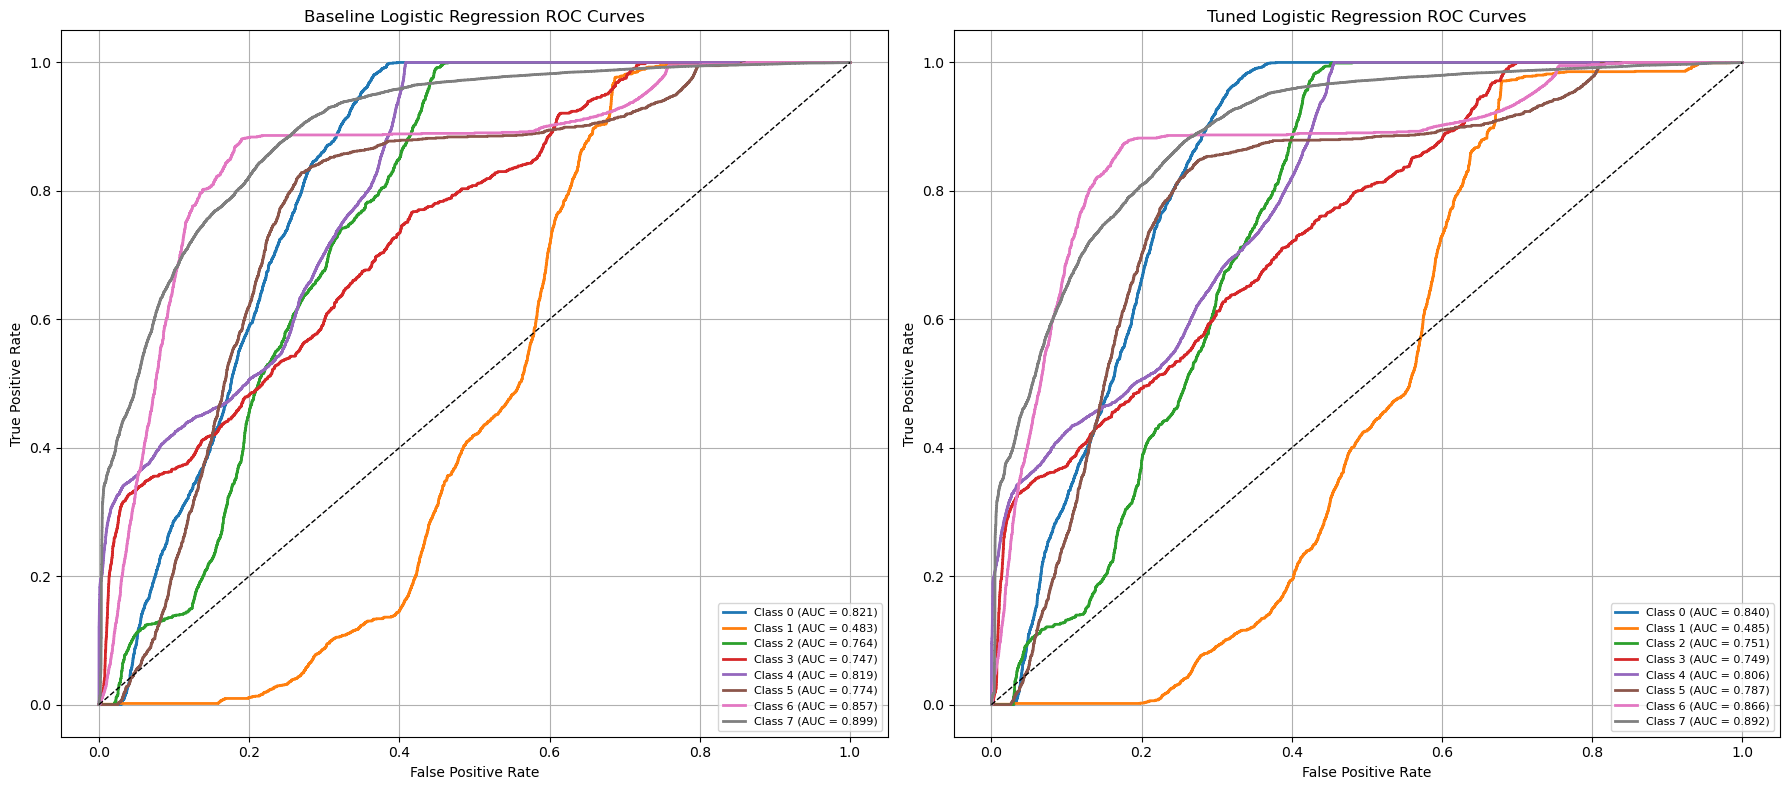

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Classes
classes = np.unique(y_train)

# Binarize labels
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = len(classes)

# Predicted probabilities
baseline_prob = lr.predict_proba(X_test)
tuned_prob = best_lr.predict_proba(X_test)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# -------------------------------
# Baseline Logistic Regression
# -------------------------------
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], baseline_prob[:, i])
    roc_auc = auc(fpr, tpr)

    axes[0].plot(
        fpr,
        tpr,
        lw=2,
        label=f"Class {classes[i]} (AUC = {roc_auc:.3f})"
    )

axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title("Baseline Logistic Regression ROC Curves")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right", fontsize=8)
axes[0].grid(True)

# -------------------------------
# Tuned Logistic Regression
# -------------------------------
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], tuned_prob[:, i])
    roc_auc = auc(fpr, tpr)

    axes[1].plot(
        fpr,
        tpr,
        lw=2,
        label=f"Class {classes[i]} (AUC = {roc_auc:.3f})"
    )

axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title("Tuned Logistic Regression ROC Curves")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right", fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.show()


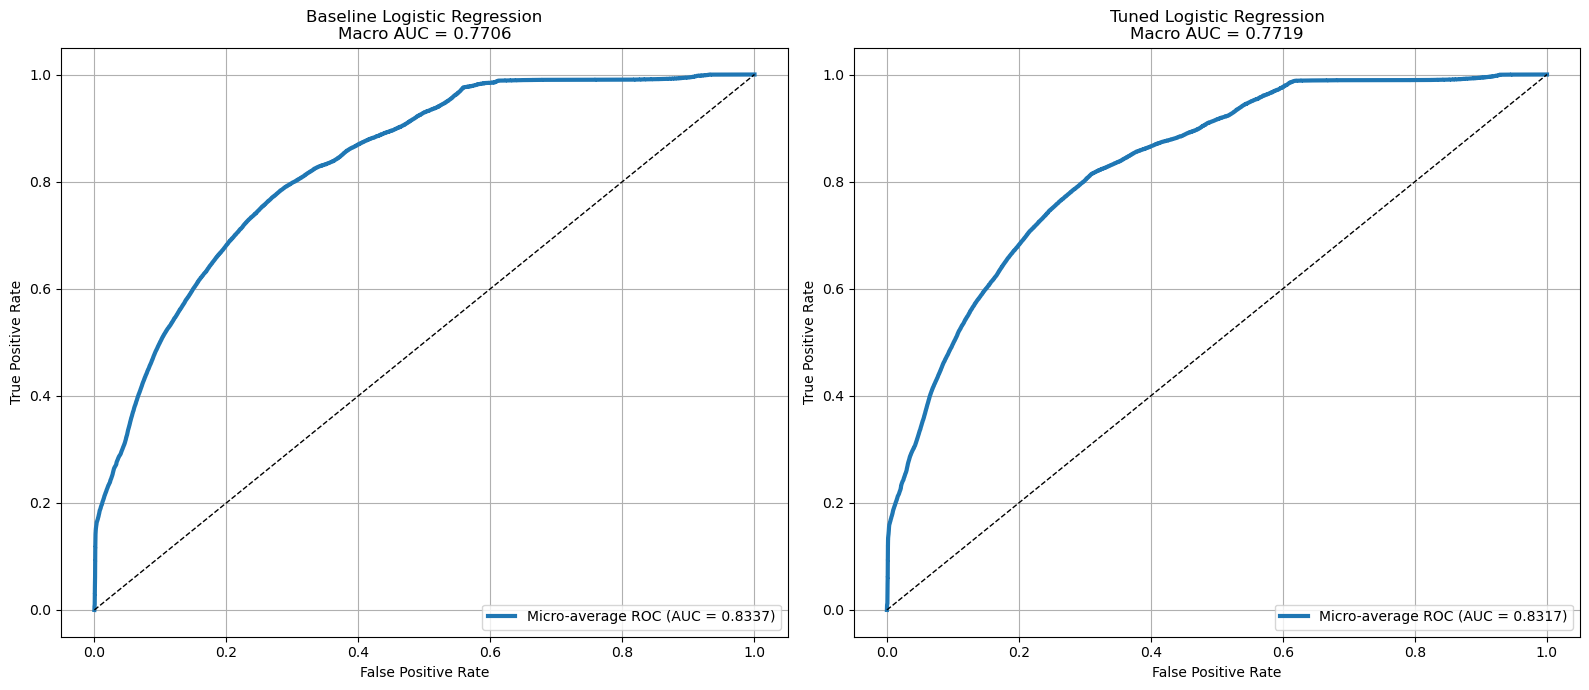

In [15]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import numpy as np

# Classes
classes = np.unique(y_train)

# Binarize test labels
y_test_bin = label_binarize(y_test, classes=classes)

# Predicted probabilities
baseline_prob = lr.predict_proba(X_test)
tuned_prob = best_lr.predict_proba(X_test)

# -----------------------------
# Baseline ROC
# -----------------------------
fpr_base, tpr_base, _ = roc_curve(
    y_test_bin.ravel(),
    baseline_prob.ravel()
)
auc_base = auc(fpr_base, tpr_base)

macro_auc_base = roc_auc_score(
    y_test_bin,
    baseline_prob,
    average='macro',
    multi_class='ovr'
)

# -----------------------------
# Tuned ROC
# -----------------------------
fpr_tuned, tpr_tuned, _ = roc_curve(
    y_test_bin.ravel(),
    tuned_prob.ravel()
)
auc_tuned = auc(fpr_tuned, tpr_tuned)

macro_auc_tuned = roc_auc_score(
    y_test_bin,
    tuned_prob,
    average='macro',
    multi_class='ovr'
)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16,7))

# Baseline
axes[0].plot(
    fpr_base,
    tpr_base,
    linewidth=3,
    label=f"Micro-average ROC (AUC = {auc_base:.4f})"
)

axes[0].plot([0,1],[0,1],'k--',linewidth=1)

axes[0].set_title(
    f"Baseline Logistic Regression\nMacro AUC = {macro_auc_base:.4f}"
)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")
axes[0].grid(True)

# Tuned
axes[1].plot(
    fpr_tuned,
    tpr_tuned,
    linewidth=3,
    label=f"Micro-average ROC (AUC = {auc_tuned:.4f})"
)

axes[1].plot([0,1],[0,1],'k--',linewidth=1)

axes[1].set_title(
    f"Tuned Logistic Regression\nMacro AUC = {macro_auc_tuned:.4f}"
)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [16]:
import pandas as pd
from sklearn.metrics import roc_auc_score

comparison = pd.DataFrame({
    "Model": ["Baseline LR", "Tuned LR"],
    "Micro AUC": [
        auc_base,
        auc_tuned
    ],
    "Macro AUC": [
        macro_auc_base,
        macro_auc_tuned
    ],
    "Weighted AUC": [
        roc_auc_score(y_test_bin, baseline_prob,
                      average='weighted', multi_class='ovr'),
        roc_auc_score(y_test_bin, tuned_prob,
                      average='weighted', multi_class='ovr')
    ]
})

print(comparison.round(4))

         Model  Micro AUC  Macro AUC  Weighted AUC
0  Baseline LR     0.8337     0.7706        0.8418
1     Tuned LR     0.8317     0.7719        0.8371
